<a href="https://colab.research.google.com/github/MuhammadUmarAshrafDE/Data-Visualization/blob/main/Week_3_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We will learn how to tell a data story with a small sales dataset.
First, we will set the purpose and audience.
Then, we will tell the story using simple charts.
After that, we will do a practical activity so everyone can apply the same steps.

Dataset, Mini Superstore, columns are Region, Product, Sales, Profit.
Goal, find which region and product drive profit.
Audience, a manager who wants quick and clear insights.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = "/content/mini_superstore_sales.csv"

df = pd.read_csv(file_path)

print("Rows and columns:", df.shape)
print(df.dtypes)
df.head(10)

Rows and columns: (150, 4)
Region      object
Product     object
Sales        int64
Profit     float64
dtype: object


,Region,Product,Sales,Profit
0,East,Phone,588,-34.17
1,West,Phone,1028,169.85
2,North,Laptop,1763,239.24
3,East,Phone,650,23.71
4,East,Desk,437,-59.85
5,West,Tablet,971,167.94
6,North,Tablet,740,64.63
7,North,Laptop,1902,250.24
8,East,Printer,572,-34.04
9,South,Laptop,250,-85.53


In [ ]:
df.describe()

,Sales,Profit
count,150.000000,150.000000
mean,1009.266667,44.189133
std,547.419813,126.258987
min,101.000000,-170.570000
25%,553.750000,-60.442500
50%,1027.500000,28.180000
75%,1441.250000,119.407500
max,1995.000000,374.270000


# Tell the story, executive **KPIs**

In [ ]:
print("Story part, executive view")

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales
total_rows = len(df)
regions = df["Region"].nunique()
products = df["Product"].nunique()

kpis = pd.DataFrame({
    "Metric": ["Total Sales", "Total Profit", "Profit Margin", "Rows", "Regions", "Products"],
    "Value": [total_sales, total_profit, profit_margin, total_rows, regions, products]
})

print(kpis.to_string(index=False))

Story part, executive view
       Metric         Value
  Total Sales 151390.000000
 Total Profit   6628.370000
Profit Margin      0.043783
         Rows    150.000000
      Regions      4.000000
     Products      6.000000


# **Story By Region**

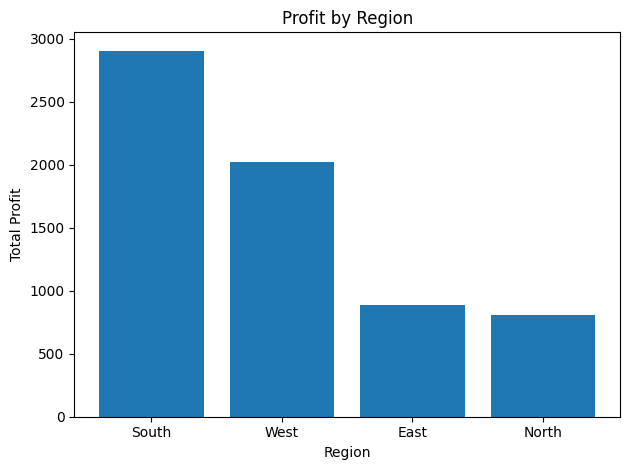

,Region,Profit
2,South,2906.94
3,West,2025.56
0,East,886.01
1,North,809.86


In [ ]:

region_profit = (df.groupby("Region", as_index=False)["Profit"]
                   .sum()
                   .sort_values("Profit", ascending=False))

plt.figure()
plt.bar(region_profit["Region"], region_profit["Profit"])
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

region_profit

# Tell the story, profit by product

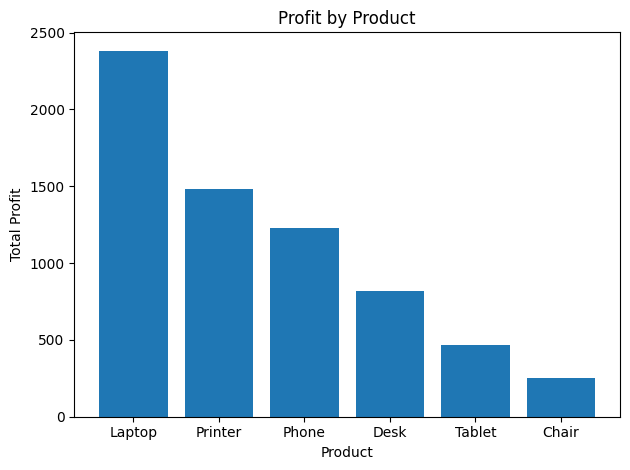

,Product,Profit
2,Laptop,2382.43
4,Printer,1481.95
3,Phone,1230.53
1,Desk,815.98
5,Tablet,467.30
0,Chair,250.18


In [ ]:


product_profit = (df.groupby("Product", as_index=False)["Profit"]
                    .sum()
                    .sort_values("Profit", ascending=False))

plt.figure()
plt.bar(product_profit["Product"], product_profit["Profit"])
plt.title("Profit by Product")
plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

product_profit

**region by product pivot**

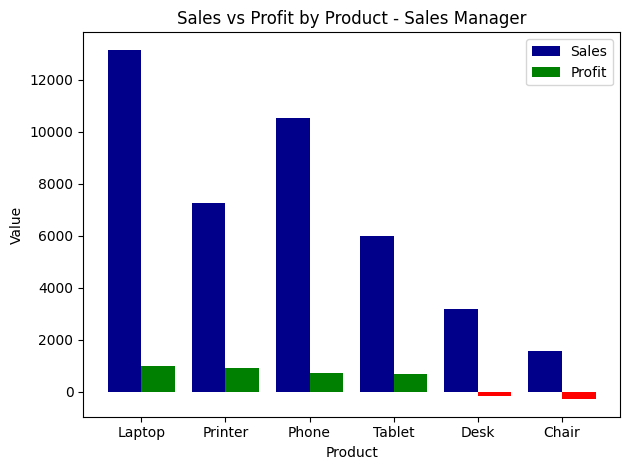

In [ ]:
best_region = ceo_view.iloc[0]["Region"]
mgr = df[df["Region"] == best_region].groupby("Product", as_index=False)[["Sales", "Profit"]].sum()
mgr = mgr.sort_values("Profit", ascending=False) # Sort by Profit

x = np.arange(len(mgr))
w = 0.4

profit_colors = ['red' if p < 0 else 'green' for p in mgr['Profit']]

plt.figure()
plt.bar(x - 0.2, mgr["Sales"], width=w, label="Sales", color='darkblue')
plt.bar(x + 0.2, mgr["Profit"], width=w, label="Profit", color=profit_colors)
plt.title(f"Sales vs Profit by Product - Sales Manager")
plt.xlabel("Product")
plt.ylabel("Value")
plt.xticks(x, mgr["Product"])
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:


pivot_profit = df.pivot_table(index="Region", columns="Product", values="Profit",
                              aggfunc="sum", fill_value=0)
pivot_profit

Product,Chair,Desk,Laptop,Phone,Printer,Tablet
Region,,,,,,
East,-103.70,151.48,278.44,510.41,192.42,-143.04
North,368.00,-207.95,678.06,-76.56,217.36,-169.05
South,-291.67,-156.03,1002.90,734.09,921.72,695.93
West,277.55,1028.48,423.03,62.59,150.45,83.46


# sales and profit comparison

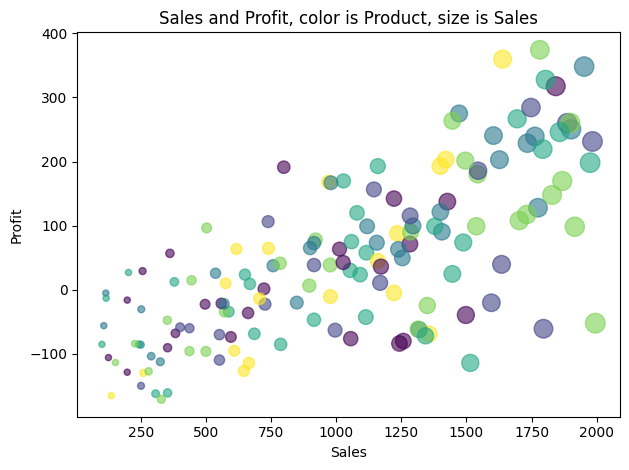

In [ ]:

plot_df = df.dropna(subset=["Sales", "Profit", "Product"]).copy()
plot_df["ProdCode"] = plot_df["Product"].astype("category").cat.codes
sizes = np.clip(plot_df["Sales"] * 0.1, 20, 300)

plt.figure()
plt.scatter(plot_df["Sales"], plot_df["Profit"], c=plot_df["ProdCode"], s=sizes, alpha=0.6)
plt.title("Sales and Profit, color is Product, size is Sales")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()






# Pick a slice of the data, for example one region.
# Make two charts that support a clear message



Summary for region, East
Product  Sales  Profit    Margin
  Phone   6411  510.41  0.079615
 Laptop   5324  278.44  0.052299
Printer   7340  192.42  0.026215
   Desk   4662  151.48  0.032492
  Chair   4590 -103.70 -0.022593
 Tablet   4319 -143.04 -0.033119


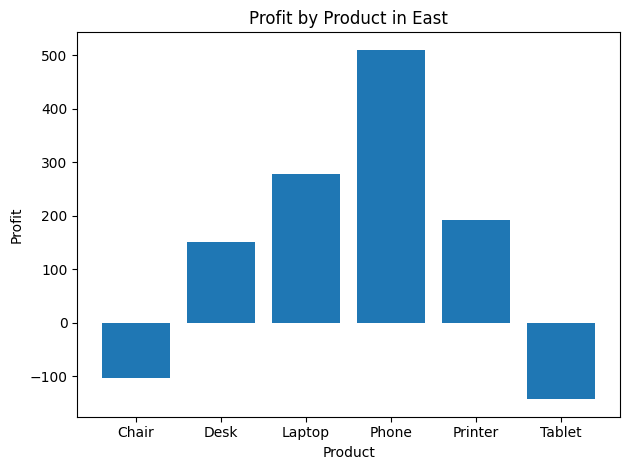

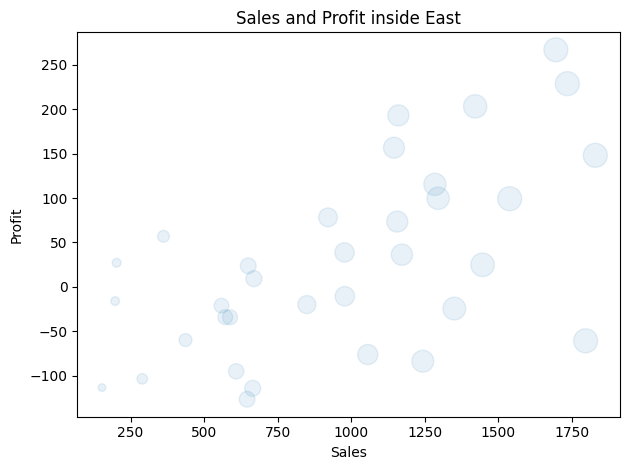


Short narrative
Audience, regional manager
Region, East
Message, which products drive profit, which need attention
Finding, top product by profit is at the top of the bar chart
Finding, some rows show high sales but weak profit, consider price or cost review


In [ ]:


chosen_region = "East"

slice_df = df[df["Region"] == chosen_region].copy()

summary = (slice_df.groupby("Product", as_index=False)
           .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")))
summary["Margin"] = summary["Profit"] / summary["Sales"]

print(f"Summary for region, {chosen_region}")
print(summary.sort_values("Profit", ascending=False).to_string(index=False))

plt.figure()
plt.bar(summary["Product"], summary["Profit"])
plt.title(f"Profit by Product in {chosen_region}")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

sizes = np.clip(slice_df["Sales"] * 0.2, 20, 300)
plt.figure()
plt.scatter(slice_df["Sales"], slice_df["Profit"], s=sizes, alpha=0.1)
plt.title(f"Sales and Profit inside {chosen_region}")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

print("\nShort narrative")
print("Audience, regional manager")
print(f"Region, {chosen_region}")
print("Message, which products drive profit, which need attention")
print("Finding, top product by profit is at the top of the bar chart")
print("Finding, some rows show high sales but weak profit, consider price or cost review")

# **CEO view**

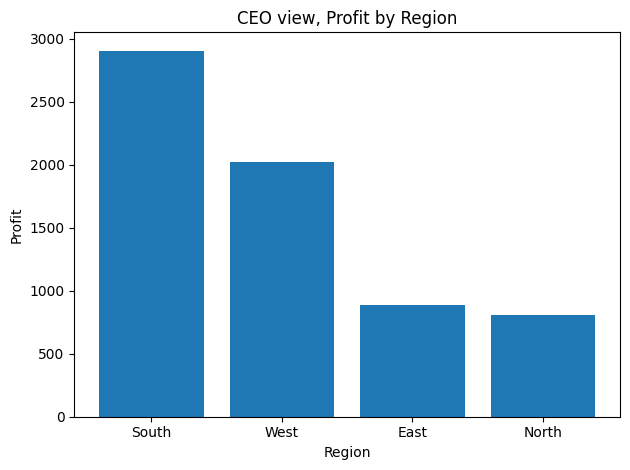

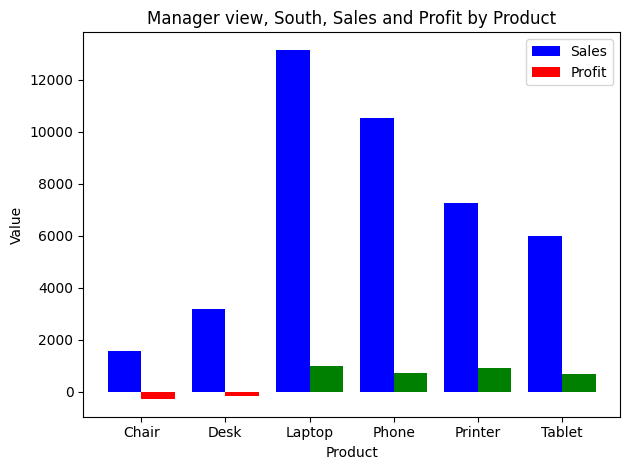

In [ ]:
ceo_view = df.groupby("Region", as_index=False)["Profit"].sum().sort_values("Profit", ascending=False)

plt.figure()
plt.bar(ceo_view["Region"], ceo_view["Profit"])
plt.title("CEO view, Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

best_region = ceo_view.iloc[0]["Region"]
mgr = df[df["Region"] == best_region].groupby("Product", as_index=False)[["Sales", "Profit"]].sum()

x = np.arange(len(mgr))
w = 0.4

profit_colors = ['red' if p < 0 else 'green' for p in mgr['Profit']]

plt.figure()
plt.bar(x - 0.2, mgr["Sales"], width=w, label="Sales", color='blue')
plt.bar(x + 0.2, mgr["Profit"], width=w, label="Profit", color=profit_colors)
plt.title(f"Manager view, {best_region}, Sales and Profit by Product")
plt.xlabel("Product")
plt.ylabel("Value")
plt.xticks(x, mgr["Product"])
plt.legend()
plt.tight_layout()
plt.show()

Summary for region, East
Product  Sales  Profit    Margin
  Phone   6411  510.41  0.079615
 Laptop   5324  278.44  0.052299
Printer   7340  192.42  0.026215
   Desk   4662  151.48  0.032492
  Chair   4590 -103.70 -0.022593
 Tablet   4319 -143.04 -0.033119


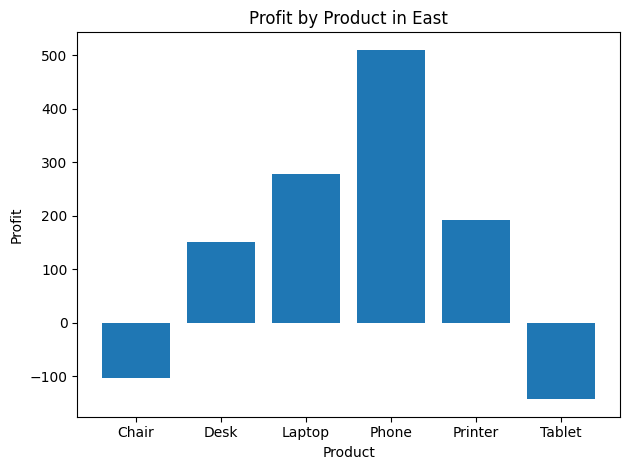

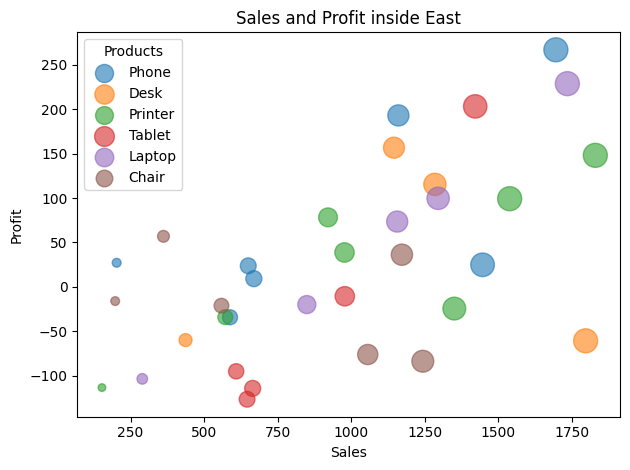

In [ ]:
chosen_region = "East"

slice_df = df[df["Region"] == chosen_region].copy()

summary = (slice_df.groupby("Product", as_index=False)
           .agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")))
summary["Margin"] = summary["Profit"] / summary["Sales"]

print(f"Summary for region, {chosen_region}")
print(summary.sort_values("Profit", ascending=False).to_string(index=False))


plt.figure()
plt.bar(summary["Product"], summary["Profit"])
plt.title(f"Profit by Product in {chosen_region}")
plt.xlabel("Product")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


sizes = np.clip(slice_df["Sales"] * 0.2, 20, 300)


colors = slice_df["Product"].astype("category").cat.codes  # tell python to give each product a color


plt.figure()

for product in slice_df["Product"].unique():
    data = slice_df[slice_df["Product"] == product]
    sizes = np.clip(data["Sales"] * 0.2, 20, 300)
    plt.scatter(data["Sales"], data["Profit"],
                s=sizes, alpha=0.6, label=product)

plt.title(f"Sales and Profit inside {chosen_region}")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.legend(title="Products")
plt.tight_layout()
plt.show()


#print("\nShort narrative")
#print("Audience, regional manager")
#print(f"Region, {chosen_region}")
#print("Message, which products drive profit, which need attention")
#print("Finding, top product by profit is at the top of the bar chart")
#print("Finding, some rows show high sales but weak profit, consider price or cost review")



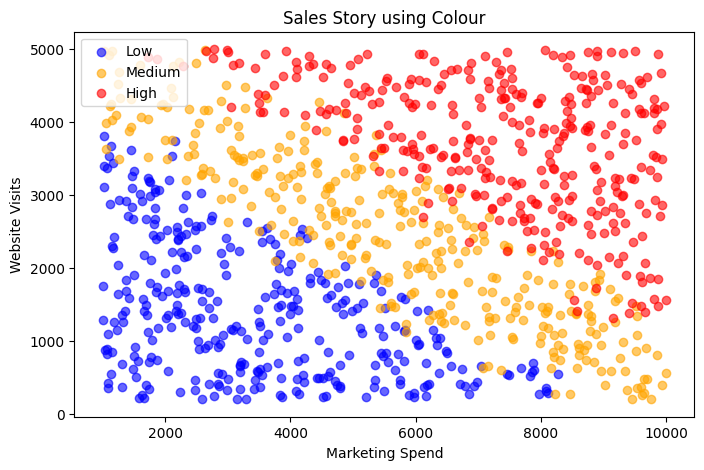

category
Low       33128.954545
Medium    54795.969697
High      76334.941176
Name: sales, dtype: float64


/tmp/ipykernel_1400/1546189961.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby("category")["sales"].mean())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(1)

n = 1000

data = pd.DataFrame({
    "marketing": np.random.randint(1000, 10000, n),
    "visits": np.random.randint(200, 5000, n),
    "satisfaction": np.random.randint(40, 100, n),
    "delivery": np.random.randint(1, 10, n),
    "discount": np.random.randint(0, 30, n),
    "region": np.random.choice(["North", "South", "East", "West"], n)
})

data["sales"] = (
    data["marketing"] * 5 +
    data["visits"] * 10 +
    data["satisfaction"] * 100 -
    data["delivery"] * 800 -
    data["discount"] * 50
)

q1 = data["sales"].quantile(0.33)
q2 = data["sales"].quantile(0.66)

data["category"] = pd.cut(
    data["sales"],
    bins=[-1, q1, q2, data["sales"].max()],
    labels=["Low", "Medium", "High"]
)

colors = {"Low": "blue", "Medium": "orange", "High": "red"}

plt.figure(figsize=(8,5))

for c in ["Low", "Medium", "High"]:
    d = data[data["category"] == c]
    plt.scatter(d["marketing"], d["visits"], c=colors[c], label=c, alpha=0.6)

plt.xlabel("Marketing Spend")
plt.ylabel("Website Visits")
plt.title("Sales Story using Colour")
plt.legend()
plt.show()

print(data.groupby("category")["sales"].mean())

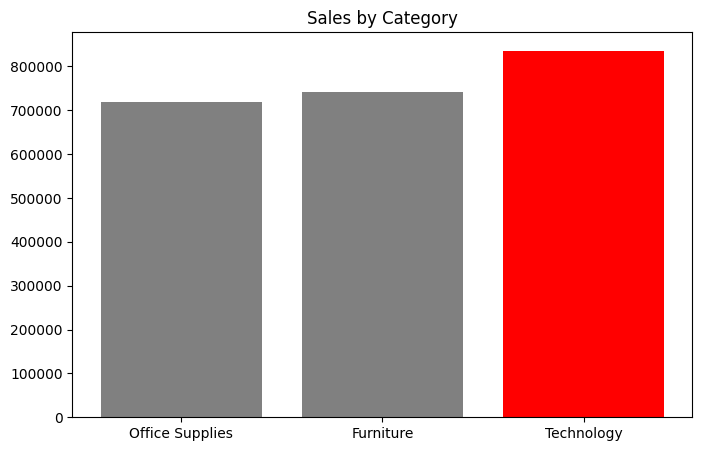

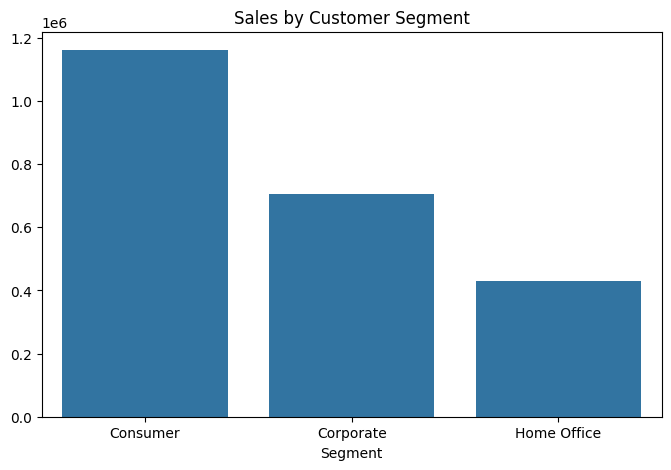

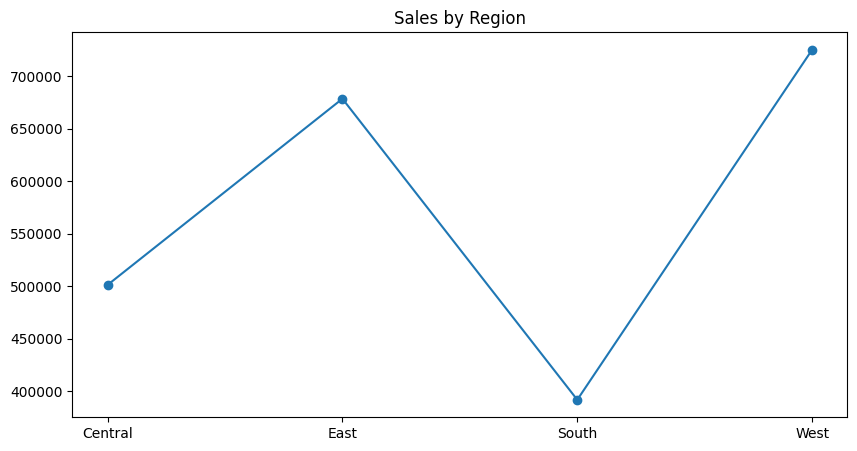

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

data.columns = data.columns.str.replace(" ", "_")

data["Order_Date"] = pd.to_datetime(data["Order_Date"])

data = data[["Category", "Segment", "Region", "Sales", "Profit"]]

plt.figure(figsize=(8,5))
sales_cat = data.groupby("Category")["Sales"].sum().sort_values()
colors = ["grey", "grey", "red"]

plt.bar(sales_cat.index, sales_cat.values, color=colors)
plt.title("Sales by Category")
plt.show()

plt.figure(figsize=(8,5))
segment = data.groupby("Segment")["Sales"].sum()
sns.barplot(x=segment.index, y=segment.values)
plt.title("Sales by Customer Segment")
plt.show()

plt.figure(figsize=(10,5))
region = data.groupby("Region")["Sales"].sum()

plt.plot(region.index, region.values, marker="o")
plt.title("Sales by Region")
plt.show()

#Bad version of the same data

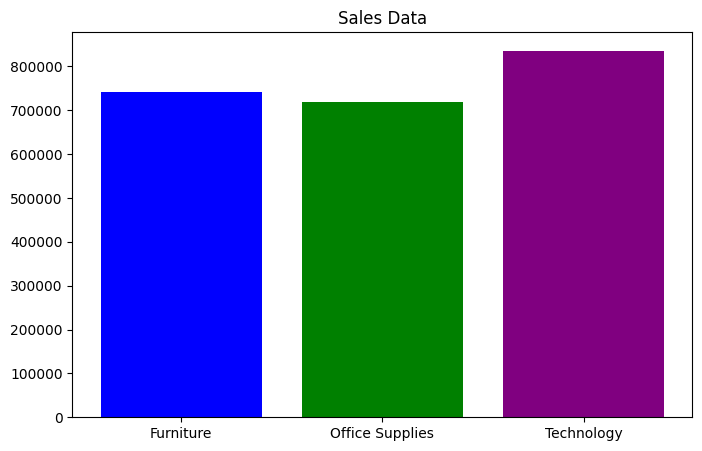

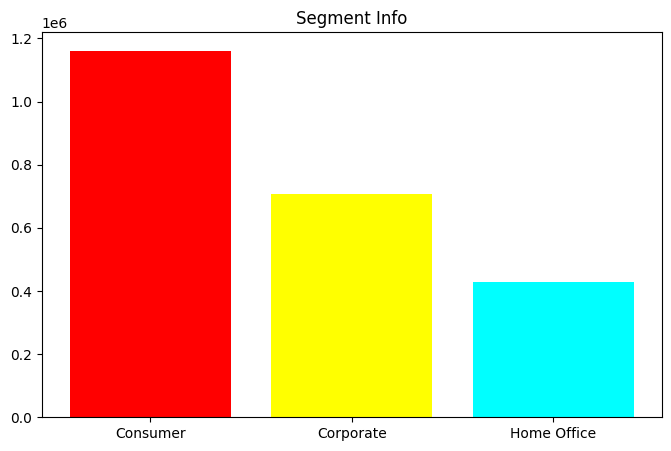

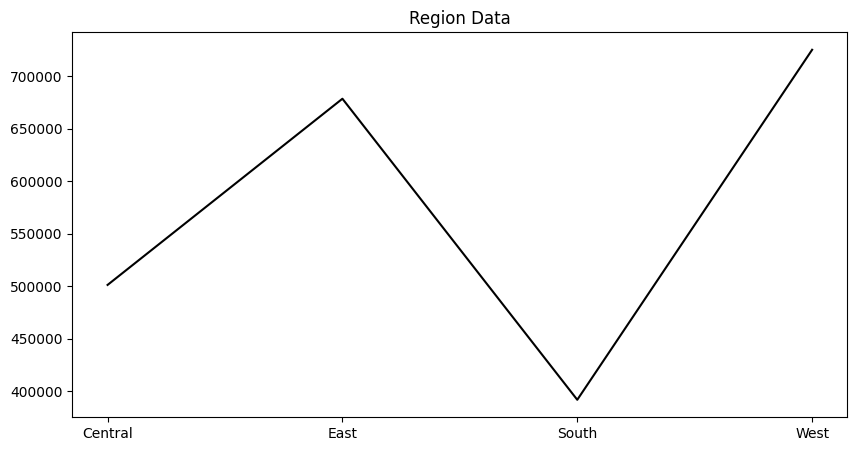

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
data.columns = data.columns.str.replace(" ", "_")

data = data[["Category", "Segment", "Region", "Sales"]]

plt.figure(figsize=(8,5))
sales_cat = data.groupby("Category")["Sales"].sum()

plt.bar(sales_cat.index, sales_cat.values, color=["blue","green","purple"])
plt.title("Sales Data")
plt.show()

plt.figure(figsize=(8,5))
segment = data.groupby("Segment")["Sales"].sum()

plt.bar(segment.index, segment.values, color=["red","yellow","cyan"])
plt.title("Segment Info")
plt.show()

plt.figure(figsize=(10,5))
region = data.groupby("Region")["Sales"].sum()

plt.plot(region.index, region.values, color="black")
plt.title("Region Data")
plt.show()